In [1]:
import os
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['savefig.dpi'] = 100

import pymcr
from pymcr.mcr import McrAR
from pymcr.regressors import OLS, NNLS
from pymcr.constraints import ConstraintNonneg, ConstraintNorm

from sklearn.linear_model import Ridge

In [2]:
#changing the directory

walki = r"C:\Users\walki"
os.chdir(walki)
print(os.getcwd())

C:\Users\walki


In [3]:
water_file = os.path.join("Leah water spectra","IR","1-27","260127 ddH2O MIRacle.dpt")
water = np.genfromtxt(fname = water_file)
water_absorbance = water[:,1]
wab = water_absorbance + 0.01

t500_file = os.path.join("Leah water spectra", "IR", "1-27", "260127 500mM Trehalose MIRacle.dpt")
t500 = np.genfromtxt(fname = t500_file)
t500_absorbance = t500[:,1]
t500ab = t500_absorbance + 0.01

In [44]:
wn = water[:,0]

tab = t500ab - (wab)
tab[tab < 0] = 0

w_from_t = wab*0.000000000001

Text(0.5, 1.0, 'Spectral Components')

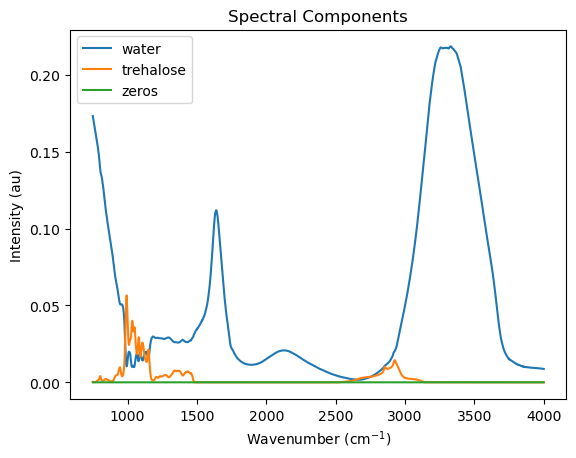

In [45]:
n_components = 3

plt.plot(wn, wab, label='water')
plt.plot(wn, tab, label='trehalose')
plt.plot(wn, w_from_t, label='zeros')
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (au)')
plt.legend(loc='best')
plt.title('Spectral Components')

In [46]:
t400_file = os.path.join("Leah water spectra", "IR", "1-27", "260127 400mM Trehalose MIRacle.dpt")
t400 = np.genfromtxt(fname = t400_file)
t400_absorbance = t400[:,1]
t400ab = t400_absorbance + 0.01

t300_file = os.path.join("Leah water spectra", "IR", "1-27", "260127 300mM Trehalose MIRacle.dpt")
t300 = np.genfromtxt(fname = t300_file)
t300_absorbance = t300[:,1]
t300ab = t300_absorbance + 0.01

t200_file = os.path.join("Leah water spectra", "IR", "1-27", "260127 200mM Trehalose MIRacle.dpt")
t200 = np.genfromtxt(fname = t200_file)
t200_absorbance = t200[:,1]
t200ab = t200_absorbance + 0.01

t100_file = os.path.join("Leah water spectra", "IR", "1-27", "260127 100mM Trehalose MIRacle.dpt")
t100 = np.genfromtxt(fname = t100_file)
t100_absorbance = t300[:,1]
t100ab = t100_absorbance + 0.01

t50_file = os.path.join("Leah water spectra", "IR", "1-27", "260127 50mM Trehalose MIRacle.dpt")
t50 = np.genfromtxt(fname = t50_file)
t50_absorbance = t500[:,1]
t50ab = t50_absorbance + 0.01

tabsorbance_matrix = np.vstack((wab, t500ab, t400ab, t300ab, t200ab, t100ab, t50ab))

In [47]:
combo = tabsorbance_matrix[:,np.newaxis,:]

In [48]:
# Stack 3 spectral vectors into 1 matrix
spectra = np.vstack((wab, tab, w_from_t))

hsi = combo

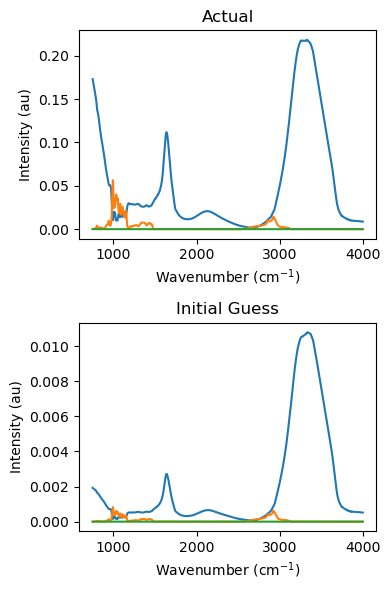

In [50]:
# Poor guess
initial_spectra = spectra*wn/67410

plt.figure(figsize=(4,6))
plt.subplot(211)
plt.plot(wn, spectra.T)
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (au)')
plt.title('Actual')

plt.subplot(212)
plt.plot(wn, initial_spectra.T)
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (au)')
plt.title('Initial Guess')

plt.tight_layout()

In [51]:
mcrar = McrAR(max_iter=100, st_regr='NNLS', c_regr=OLS(), tol_increase=10,
               #added tol_increase to remove error and exiting based off of https://github.com/usnistgov/pyMCR/issues/43
                c_constraints=[ConstraintNonneg(), ConstraintNorm()])

mcrar.fit(hsi.reshape((-1, wn.size)), ST = initial_spectra, verbose=True)
print('\nFinal MSE: {:.7e}'.format(mcrar.err[-1]))

Iter: 1 (C)	mse: 6.4126e-03
Iter: 1 (ST)	mse: 2.3675e-06
Iter: 2 (C)	mse: 1.5047e-06
Iter: 2 (ST)	mse: 7.6987e-07
Iter: 3 (C)	mse: 5.4205e-07
Iter: 3 (ST)	mse: 3.0601e-07
Iter: 4 (C)	mse: 2.1117e-07
Iter: 4 (ST)	mse: 1.5365e-07
Iter: 5 (C)	mse: 1.1474e-07
Iter: 5 (ST)	mse: 8.6805e-08
Iter: 6 (C)	mse: 6.7720e-08
Iter: 6 (ST)	mse: 5.3024e-08
Iter: 7 (C)	mse: 4.4396e-08
Iter: 7 (ST)	mse: 3.6400e-08
Iter: 8 (C)	mse: 3.2532e-08
Iter: 8 (ST)	mse: 2.7982e-08
Iter: 9 (C)	mse: 2.6600e-08
Iter: 9 (ST)	mse: 2.3677e-08
Iter: 10 (C)	mse: 2.3297e-08
Iter: 10 (ST)	mse: 2.1130e-08
Iter: 11 (C)	mse: 2.1337e-08
Iter: 11 (ST)	mse: 1.9523e-08
Iter: 12 (C)	mse: 2.0045e-08
Iter: 12 (ST)	mse: 1.8459e-08
Iter: 13 (C)	mse: 1.9079e-08
Iter: 13 (ST)	mse: 1.7656e-08
Iter: 14 (C)	mse: 1.8351e-08
Iter: 14 (ST)	mse: 1.7030e-08
Iter: 15 (C)	mse: 1.7829e-08
Iter: 15 (ST)	mse: 1.6565e-08
Iter: 16 (C)	mse: 1.7358e-08
Iter: 16 (ST)	mse: 1.6168e-08
Iter: 17 (C)	mse: 1.6981e-08
Iter: 17 (ST)	mse: 1.5853e-08
Iter: 18 (C)	ms

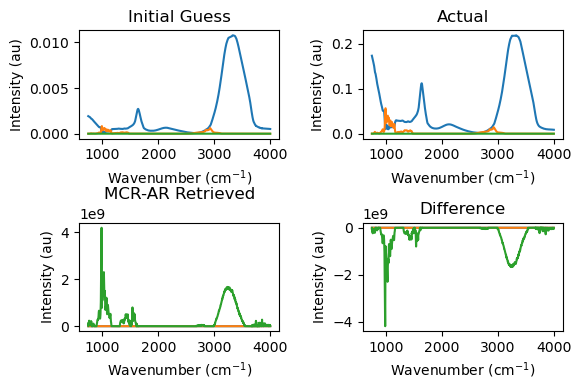

In [52]:
plt.figure(figsize=(6,4))
plt.subplot(221)
plt.plot(wn, initial_spectra.T)
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (au)')
plt.title('Initial Guess')

plt.subplot(222)
plt.plot(wn, spectra.T)
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (au)')
plt.title('Actual')

plt.subplot(223)
plt.plot(wn, mcrar.ST_opt_.T)
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (au)')
plt.title('MCR-AR Retrieved')

plt.subplot(224)
plt.plot(wn, spectra.T - mcrar.ST_opt_.T)
plt.xlabel(r'Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (au)')
plt.title('Difference')

plt.tight_layout()
plt.savefig('mcr_spectra_retr.png')
plt.show()